In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import cv2

import math

import os

In [15]:
def box_sum_same(x: torch.Tensor, w: int, pad_mode: str = "replicate"):
    """
    x: (N,1,H,W)
    returns: (N,1,H,W) where each pixel is sum over a w×w window
    """
    assert w % 2 == 1, "Window size must be odd"
    pad_size = w // 2
    y = F.avg_pool2d(x, kernel_size=w, stride=1, padding=pad_size) * (w * w)
    return y

In [16]:
def get_blockwise_orientation(
    source_image: torch.Tensor,
    block_size: int = 8,
):
    dev = source_image.device
    dtype = source_image.dtype

    sobel_x = torch.tensor(
        [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=dtype, device=dev
    ).view(1, 1, 3, 3)
    sobel_y = torch.tensor(
        [[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=dtype, device=dev
    ).view(1, 1, 3, 3)
    blur = transforms.GaussianBlur(kernel_size=5)

    img = source_image.clone()
    img = blur(img.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)

    Gx = F.conv2d(img.unsqueeze(0).unsqueeze(0), sobel_x, padding=1)
    Gy = F.conv2d(img.unsqueeze(0).unsqueeze(0), sobel_y, padding=1)

    Gx2 = Gx * Gx
    Gy2 = Gy * Gy
    Gxy = Gx * Gy

    kernel = torch.ones(
        (1, 1, block_size, block_size), dtype=Gx2.dtype, device=Gx2.device
    )

    sum_Gx2 = F.avg_pool2d(Gx2, kernel_size=block_size, stride=block_size) * (
        block_size * block_size
    )
    sum_Gy2 = F.avg_pool2d(Gy2, kernel_size=block_size, stride=block_size) * (
        block_size * block_size
    )
    sum_Gxy = F.avg_pool2d(Gxy, kernel_size=block_size, stride=block_size) * (
        block_size * block_size
    )

    Vx = 2.0 * sum_Gxy.squeeze(0).squeeze(0)
    Vy = sum_Gx2.squeeze(0).squeeze(0) - sum_Gy2.squeeze(0).squeeze(0)

    theta = 0.5 * torch.atan2(Vx, Vy + 1e-8)

    Tx = torch.cos(2.0 * theta)
    Ty = torch.sin(2.0 * theta)

    Tprime_x = blur(Tx.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)
    Tprime_y = blur(Ty.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)

    theta = 0.5 * torch.atan2(Tprime_y, Tprime_x)
    orientation_map = torch.remainder(theta, torch.pi)

    return orientation_map

def get_freq_map(
    img: torch.Tensor
):
    # dummy values for now
    return torch.full_like(img, 0.35)


def compute_spatial_gradient(tensor_map):
    kernel_x = (
        torch.tensor([[-1.0, 0.0, 1.0]], device=tensor_map.device).view(1, 1, 1, 3) / 2.0
    )
    kernel_y = (
        torch.tensor([[-1.0], [0.0], [1.0]], device=tensor_map.device).view(1, 1, 3, 1)
        / 2.0
    )

    dx = F.conv2d(tensor_map.unsqueeze(0).unsqueeze(0), kernel_x, padding=(0, 1)).squeeze(0).squeeze(0)
    dy = F.conv2d(tensor_map.unsqueeze(0).unsqueeze(0), kernel_y, padding=(1, 0)).squeeze(0).squeeze(0)

    return dx, dy


def compute_phasor_gradient(phase_map):
    # Convert to complex phasor: e^(i * phi)
    phasor = torch.exp(1j * phase_map)

    # Gradient in X
    # Conj(x) * x_next is equivalent to e^(-i*phi) * e^(i*phi_next) = e^(i * d_phi)
    # The angle of this result gives the wrapped difference in range [-pi, pi]
    diff_x = phasor[..., :, 1:] * torch.conj(phasor[..., :, :-1])
    dx = torch.angle(diff_x)
    dx = F.pad(dx, (0, 1, 0, 0))  # Pad to match size

    # Gradient in Y
    diff_y = phasor[..., 1:, :] * torch.conj(phasor[..., :-1, :])
    dy = torch.angle(diff_y)
    dy = F.pad(dy, (0, 0, 0, 1))

    return dx, dy


def structure_loss(phase_c_params, spiral_phase, target_vector_field):
    # dx_c, dy_c = compute_spatial_gradient(phase_c_params)
    # dx_s, dy_s = compute_spatial_gradient(spiral_phase)

    dx_c, dy_c = compute_phasor_gradient(phase_c_params)
    dx_s, dy_s = compute_phasor_gradient(spiral_phase)

    grad_total_x = dx_c + dx_s
    grad_total_y = dy_c + dy_s

    loss_flow = F.mse_loss(grad_total_x, target_vector_field[:, 0]) + F.mse_loss(
        grad_total_y, target_vector_field[:, 1]
    )

    return loss_flow


def ssim_loss(generated, target, window_size=11):
    """
    Basic implementation of SSIM as a loss (1 - SSIM).
    assumes images are shape [Batch, 1, H, W]
    """
    # Create a simple gaussian window
    sigma = 1.5
    gauss = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    gauss = torch.exp(-(gauss**2) / (2 * sigma**2))
    gauss = gauss / gauss.sum()
    window = gauss[:, None] @ gauss[None, :]
    window = window.to(generated.device).view(1, 1, window_size, window_size)

    # Helper to filter
    def filter2d(img):
        return F.conv2d(img, window, padding=window_size // 2, groups=1)

    mu1 = filter2d(generated)
    mu2 = filter2d(target)

    mu1_sq = mu1**2
    mu2_sq = mu2**2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = filter2d(generated**2) - mu1_sq
    sigma2_sq = filter2d(target**2) - mu2_sq
    sigma12 = filter2d(generated * target) - mu1_mu2

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / (
        (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)
    )

    return 1 - ssim_map.mean()


def spectral_loss(pred, target):
    eps = 1e-8
    fft_pred = torch.fft.rfft2(pred, norm="ortho")
    fft_target = torch.fft.rfft2(target, norm="ortho")

    mag_pred = torch.abs(fft_pred)
    mag_target = torch.abs(fft_target)

    log_mag_pred = torch.log(mag_pred + eps)
    log_mag_target = torch.log(mag_target + eps)

    return F.l1_loss(log_mag_pred, log_mag_target)

# from https://openaccess.thecvf.com/content/ICCV2021/papers/Jiang_Focal_Frequency_Loss_for_Image_Reconstruction_and_Synthesis_ICCV_2021_paper.pdf
def focal_loss(pred, target, alpha=1.0):
    eps = 1e-8
    fft_pred = torch.fft.rfft2(pred, norm="ortho")
    fft_target = torch.fft.rfft2(target, norm="ortho")

    diff_fft_val = fft_target - fft_pred
    diff_fft_mag = torch.abs(diff_fft_val)

    distance = torch.square(diff_fft_mag)
    weight = torch.pow(diff_fft_mag, alpha)

    return torch.mean(weight * distance)

def fft_loss(pred, target):
    eps = 1e-8
    fft_pred = torch.fft.rfft2(pred, norm="ortho")
    fft_target = torch.fft.rfft2(target, norm="ortho")

    real_pred = torch.real(fft_pred)
    imag_pred = torch.imag(fft_pred)

    real_target = torch.real(fft_target)
    imag_target = torch.imag(fft_target)

    return F.mse_loss(real_pred, real_target) + F.mse_loss(imag_pred, imag_target)


def multiscale_mse_loss(pred, target, scales=[1, 2, 4, 8, 16]):
    loss = 0
    for scale in scales:
        if scale == 1:
            loss += F.mse_loss(pred, target)
        else:
            p_down = F.avg_pool2d(pred.unsqueeze(0).unsqueeze(0), kernel_size=scale, stride=scale)
            t_down = F.avg_pool2d(target.unsqueeze(0).unsqueeze(0), kernel_size=scale, stride=scale)
            loss += F.mse_loss(p_down, t_down)
    return loss

In [17]:
def train_structure_loss(
    target_image, n_epochs, target_vector_field, spiral_phase_map=None, lr=5e-1
):
    h, w = target_image.shape
    # phase_map = torch.zeros_like(target_image, requires_grad=True)
    x_coords = torch.linspace(torch.pi, 2 * torch.pi, w)
    y_coords = torch.linspace(torch.pi, 2 * torch.pi, h)
    yy, xx = torch.meshgrid(y_coords, x_coords, indexing="ij")
    phase_init = xx
    phase_map = nn.Parameter(phase_init.clone())

    if spiral_phase_map is None:
        spiral_phase_map = torch.zeros_like(target_image, requires_grad=False)

    # training settings
    optimizer = torch.optim.Adam([phase_map], lr=lr)

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        generated_fingerprint = 0.5 * ( 
            1.0 + torch.cos(phase_map + spiral_phase_map)
        )

        recon_loss = multiscale_mse_loss(
            generated_fingerprint, target_image
        )

        structure_simil_loss = ssim_loss(
            generated_fingerprint.unsqueeze(0).unsqueeze(0),
            target_image.unsqueeze(0).unsqueeze(0),
        )
        structure_l = structure_loss(
            phase_map, spiral_phase_map, target_vector_field=target_vector_field
        )
        spectral_l = focal_loss(generated_fingerprint, target_image)

        alpha = epoch / n_epochs / 50.0  # Ramp up from 0 to 1 over 500 epochs
        recon_loss_weight = 5.0 
        ssim_loss_weight = 5.0 
        total_loss = 0.0 * structure_l + recon_loss_weight * recon_loss + ssim_loss_weight * structure_simil_loss + alpha * spectral_l

        # Backpropagate and update parameters
        total_loss.backward()
        optimizer.step()

        # Print loss values
        if epoch % 100 == 0 or epoch == 1 or epoch == n_epochs - 1:
            print(f"Structure Loss: {structure_l:.6f} | Recon Loss: {recon_loss:.6f} | Structure Simil Loss: {structure_simil_loss:.6f} | Spectral loss: {spectral_l:.6f} | Total Loss: {total_loss:.6f}")

    return phase_map

In [18]:
def train_spiral_no_spiral(
    target_image_with_spiral, target_image_without_spiral, n_epochs, spiral_phase_map=None, lr=5e-1
):
    assert target_image_with_spiral.shape == target_image_without_spiral.shape, "Input images must have the same shape"
    h, w = target_image_with_spiral.shape
    # phase_map = torch.zeros_like(target_image, requires_grad=True)
    x_coords = torch.linspace(torch.pi, 2 * torch.pi, w)
    y_coords = torch.linspace(torch.pi, 2 * torch.pi, h)
    yy, xx = torch.meshgrid(y_coords, x_coords, indexing="ij")
    phase_init = xx
    phase_map = nn.Parameter(phase_init.clone())

    if spiral_phase_map is None:
        spiral_phase_map = torch.zeros_like(target_image_with_spiral, requires_grad=False)

    # training settings
    optimizer = torch.optim.Adam([phase_map], lr=lr)

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        generated_fingerprint_with_spiral = 0.5 * (1.0 + torch.cos(phase_map + spiral_phase_map))

        recon_loss = multiscale_mse_loss(generated_fingerprint_with_spiral, target_image_with_spiral)
        structure_simil_loss = ssim_loss(
            generated_fingerprint_with_spiral
            .unsqueeze(0).unsqueeze(0),
            target_image_with_spiral.unsqueeze(0).unsqueeze(0),
        )

        generated_fingerprint_no_spiral = 0.5 * (1.0 + torch.cos(phase_map))
        phaseless_recon_loss = multiscale_mse_loss(generated_fingerprint_no_spiral, target_image_without_spiral)
        ssim_no_spiral_loss = ssim_loss(
            generated_fingerprint_no_spiral.unsqueeze(0).unsqueeze(0),
            target_image_without_spiral.unsqueeze(0).unsqueeze(0),
        )


        recon_loss_weight = 5.0
        ssim_loss_weight = 5.0
        total_loss = (
            + recon_loss_weight * recon_loss
            + ssim_loss_weight * structure_simil_loss
            + recon_loss_weight * phaseless_recon_loss
            + ssim_loss_weight * ssim_no_spiral_loss
        )

        # Backpropagate and update parameters
        total_loss.backward()
        optimizer.step()

        # Print loss values
        if epoch % 100 == 0 or epoch == 1 or epoch == n_epochs - 1:
            print(
                f"Recon Loss: {recon_loss:.6f} | SSIM Loss: {structure_simil_loss:.6f} | Phaseless Recon Loss: {phaseless_recon_loss:.6f} | SSIM No Spiral Loss: {ssim_no_spiral_loss:.6f} | Total Loss: {total_loss:.6f}"
            )

    return phase_map

In [19]:
def wrap_to_pi(x):
    """Wraps phase to (-pi, pi]"""
    return (x + np.pi / 2.0) % (np.pi) - np.pi /2.0


def itoh_2d_unwrap(wrapped_phase):
    rows, cols = wrapped_phase.shape
    unwrapped_phase = np.zeros_like(wrapped_phase)

    # 1. Initialize starting point
    unwrapped_phase[0, 0] = wrapped_phase[0, 0]

    # 2. Unwrap the first row (Reference)
    for j in range(1, cols):
        diff = wrapped_phase[0, j] - wrapped_phase[0, j - 1]
        unwrapped_phase[0, j] = unwrapped_phase[0, j - 1] + wrap_to_pi(diff)

    # 3. Unwrap all columns using the first row as the seed
    for j in range(cols):
        for i in range(1, rows):
            diff = wrapped_phase[i, j] - wrapped_phase[i - 1, j]
            unwrapped_phase[i, j] = unwrapped_phase[i - 1, j] + wrap_to_pi(diff)

    return unwrapped_phase


def unwrap(orientation_map):
    """
    Implements the greedy unwrapping strategy from Feng & Jain Eq. 12.
    Expects orientation_map in radians, wrapped in [0, pi] or [-pi/2, pi/2].
    """
    if torch.is_tensor(orientation_map):
        ori = orientation_map.detach().cpu().numpy()
    else:
        ori = orientation_map.copy()
    
    unwrapped = itoh_2d_unwrap(ori)
    print("Unwrapped orientation map min/max:", unwrapped.min(), unwrapped.max())
    return torch.from_numpy(unwrapped)

def fix_edges(mp):
    mask = torch.ones_like(mp)
    mask[..., 0, :] = 0  # Top
    mask[..., -1, :] = 0  # Bottom
    mask[..., :, 0] = 0  # Left
    mask[..., :, -1] = 0  # Right

    # 2. Convolution logic to average valid neighbors
    kernel = torch.ones(1, 1, 3, 3, device=mp.device)
    to_conv = mp * mask
    print("2conv shape", to_conv.shape)

    neighbor_sum = (
        F.conv2d(to_conv.unsqueeze(0).unsqueeze(0), kernel, padding=1).squeeze(0).squeeze(0)
    )
    neighbor_count = (
        F.conv2d(mask.unsqueeze(0).unsqueeze(0), kernel, padding=1).squeeze(0).squeeze(0)
    )

    neighbor_count[neighbor_count == 0] = 1
    interpolated = neighbor_sum / neighbor_count

    # 4. Replace ONLY the border pixels
    return torch.where(mask.bool(), mp, interpolated)

In [20]:
from torchvision import transforms

spiral_image = cv2.imread("images/spiral_phase.jpg", cv2.IMREAD_GRAYSCALE)
spiral_image = spiral_image / 255.0
h, w = spiral_image.shape

# normalize
target_spiral_image = torch.from_numpy(spiral_image).float()
target_spiral_image = target_spiral_image / target_spiral_image.max()

non_spiral_image = cv2.imread("images/cont_phase.jpg", cv2.IMREAD_GRAYSCALE)
non_spiral_image = non_spiral_image / 255.0

target_non_spiral_image = torch.from_numpy(non_spiral_image).float()
target_non_spiral_image = target_non_spiral_image / target_non_spiral_image.max()

# plt.imshow(target_spiral_image.numpy(), cmap="gray")
# plt.axis("off")
# plt.colorbar()
# plt.show()
# spiral phase initialization
spiral_phase_coords = [(95, 128), (40, 55), (128, 200)]
spiral_phase_polarities = [+1, -1, -1]

spiral_phase = torch.zeros(h, w)
y_range = torch.arange(h)
x_range = torch.arange(w)

Y, X = torch.meshgrid(y_range, x_range, indexing="ij")
for (yy, xx), polarity in zip(spiral_phase_coords, spiral_phase_polarities):
    spiral_phase += polarity * torch.arctan2(Y - yy, X - xx)

spiral_phase_map = torch.tensor(spiral_phase, requires_grad=False)

C:\Users\leanh\AppData\Local\Temp\ipykernel_21500\2068163624.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spiral_phase_map = torch.tensor(spiral_phase, requires_grad=False)


Recon Loss: 1.064909 | SSIM Loss: 0.947302 | Phaseless Recon Loss: 1.066201 | SSIM No Spiral Loss: 0.953782 | Total Loss: 20.160969
Recon Loss: 1.064263 | SSIM Loss: 0.946386 | Phaseless Recon Loss: 1.065485 | SSIM No Spiral Loss: 0.952805 | Total Loss: 20.144699
Recon Loss: 0.997398 | SSIM Loss: 0.858757 | Phaseless Recon Loss: 0.992317 | SSIM No Spiral Loss: 0.859789 | Total Loss: 18.541309
Recon Loss: 0.925169 | SSIM Loss: 0.781982 | Phaseless Recon Loss: 0.915235 | SSIM No Spiral Loss: 0.778762 | Total Loss: 17.005741
Recon Loss: 0.850116 | SSIM Loss: 0.714806 | Phaseless Recon Loss: 0.836657 | SSIM No Spiral Loss: 0.708091 | Total Loss: 15.548344
Recon Loss: 0.773909 | SSIM Loss: 0.654864 | Phaseless Recon Loss: 0.758023 | SSIM No Spiral Loss: 0.645317 | Total Loss: 14.160564
Recon Loss: 0.698532 | SSIM Loss: 0.601110 | Phaseless Recon Loss: 0.681039 | SSIM No Spiral Loss: 0.589540 | Total Loss: 12.851110
Recon Loss: 0.625900 | SSIM Loss: 0.552907 | Phaseless Recon Loss: 0.607421 

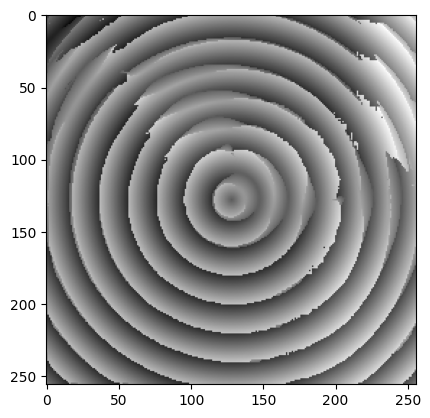

In [21]:
# phase_map = torch.acos(target_image) - spiral_phase_map
phase_map = train_spiral_no_spiral(
    target_image_with_spiral=target_spiral_image,
    target_image_without_spiral=target_non_spiral_image,
    n_epochs=10000,
    spiral_phase_map=spiral_phase_map,
    lr=1e-3
)

plt.imshow(phase_map.detach().cpu().numpy(), cmap="gray")
final_trained_fingerprint = 0.5 * (1.0 + torch.cos(phase_map + spiral_phase_map))

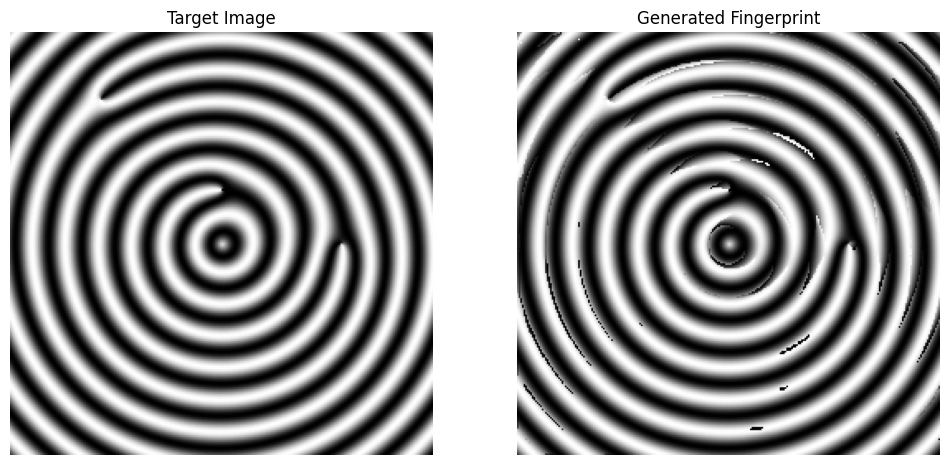

In [27]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) 
plt.title("Target Image")
plt.imshow(target_spiral_image.detach().cpu(), cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Generated Fingerprint")
plt.imshow(final_trained_fingerprint.detach().cpu(), cmap="gray")
plt.axis("off")
cv2.imwrite("../images/gen_fprint.png", (final_trained_fingerprint.detach().cpu().numpy() * 255).astype(np.uint8))
plt.show()

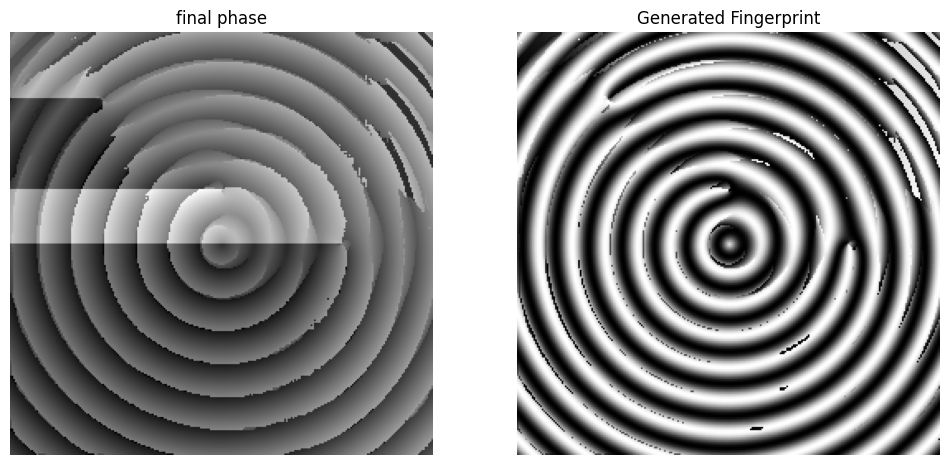

In [28]:
final_trained_fingerprint = 0.5 * (1.0 + torch.cos(phase_map + spiral_phase_map))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("final phase")
plt.imshow((phase_map + spiral_phase_map).detach().cpu(), cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Generated Fingerprint")
plt.imshow(final_trained_fingerprint.detach().cpu(), cmap="gray")
plt.axis("off")
plt.show()

Parameter containing:
tensor([[1.8947, 2.1147, 2.3283,  ..., 7.4723, 7.2625, 7.0682],
        [2.0986, 2.3360, 3.8469,  ..., 7.7434, 7.4901, 7.2647],
        [2.3196, 2.6037, 3.6036,  ..., 8.0701, 7.7558, 7.4874],
        ...,
        [3.8441, 3.6029, 3.3606,  ..., 3.1471, 3.3649, 3.6065],
        [4.0694, 3.8416, 3.6036,  ..., 3.3810, 3.6223, 3.8406],
        [4.2737, 4.0589, 3.8319,  ..., 3.6090, 3.8295, 4.0380]],
       requires_grad=True)


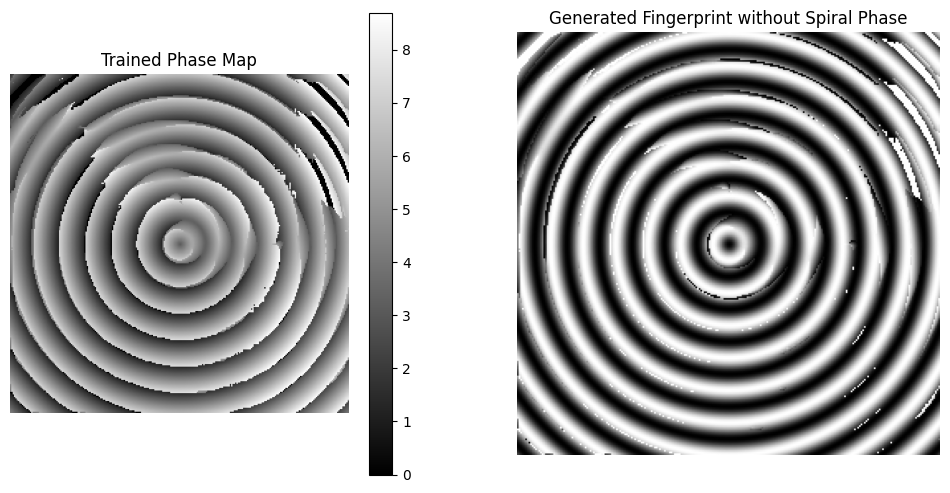

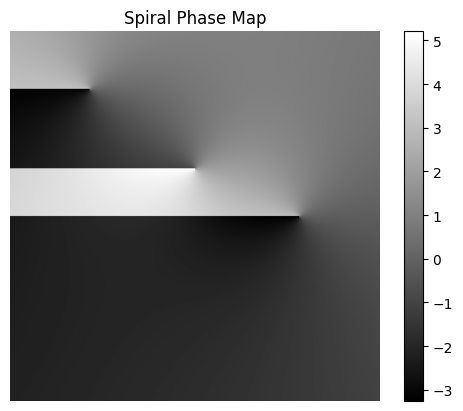

In [29]:
print(phase_map)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(phase_map.detach().cpu(), cmap="gray")
plt.colorbar()
plt.title("Trained Phase Map")
plt.axis("off")

plt.subplot(1, 2, 2)
final_fingerprint_without_spiral = 0.5 * (1.0 + torch.cos(phase_map))
plt.imshow(final_fingerprint_without_spiral.detach().cpu(), cmap="gray")
plt.title("Generated Fingerprint without Spiral Phase")
plt.axis("off")

plt.show()
plt.imshow(spiral_phase_map.detach().cpu(), cmap="gray")
plt.colorbar()
plt.title("Spiral Phase Map")
plt.axis("off")
plt.show()

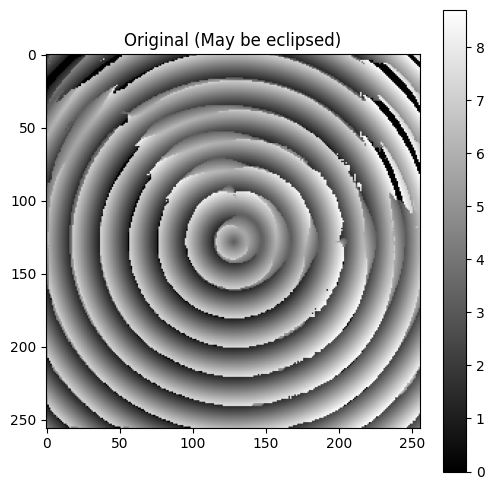

In [30]:

# 5. Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original (May be eclipsed)")
# Convert original to numpy for plotting, handling potential infinite values roughly
original_np = phase_map.detach().cpu().squeeze().numpy()
plt.imshow(original_np, cmap='gray')
plt.colorbar()

plt.tight_layout()
plt.show()

In [26]:
original_fprint = cv2.imread("../images/cont_phase.jpg", cv2.IMREAD_GRAYSCALE)
gen_fprint = cv2.imread("../images/gen_fprint.png", cv2.IMREAD_GRAYSCALE)

# check if path exists
print(os.path.exists("../images/gen_fprint.png"))

# normalize both
original_fprint = original_fprint / original_fprint.max()
gen_fprint = gen_fprint / gen_fprint.max()

of = torch.from_numpy(original_fprint)
gf = torch.from_numpy(gen_fprint)

print(of.shape, gf.shape)

fft_of = torch.fft.rfft2(of, norm='ortho')
fft_gf = torch.fft.rfft2(gf, norm='ortho')

mag_fft_of = torch.log(torch.abs(fft_of) + 1e-8)
mag_fft_gf = torch.log(torch.abs(fft_gf) + 1e-8)

phase_fft_of = torch.angle(fft_of)
phase_fft_gf = torch.angle(fft_gf)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(mag_fft_of, cmap='inferno')
plt.colorbar()


plt.subplot(1, 2, 2)
plt.imshow(mag_fft_gf, cmap="inferno")
plt.colorbar()
plt.show()


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(phase_fft_of, cmap="twilight")

plt.subplot(1, 2, 2)
plt.imshow(phase_fft_gf, cmap="twilight")
plt.show()

False


AttributeError: 'NoneType' object has no attribute 'max'